# Загрязнение воздуха и продолжительность жизни в регионах России (2015)
**Эконометрический проект: EDA и базовые IV-проверки**

Кросс-секция: 1 строка = 1 субъект РФ за 2015 год. Зависимая переменная — ожидаемая продолжительность жизни (`life_expectancy`). Основная объясняющая переменная — лог выбросов загрязняющих веществ на душу (`ln_emissions_h1_pc`).

## 1. Постановка задачи

**Исследовательский вопрос.** Связано ли более высокое атмосферное загрязнение с более низкой ожидаемой продолжительностью жизни в регионах России?

**Рабочая гипотеза.** Более высокий уровень выбросов на душу связан с более низкой `life_expectancy`.

**Ограничение интерпретации.** Кросс-секция небольшая, источники неоднородны, а доступные IV не идеальны.

**Замечание по статистическим тестам.** Гипотезы проекта в основном направленные по знаку.

In [23]:
# Импорты и настройка отображения
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from linearmodels.iv import IV2SLS

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', '{:,.4f}'.format)
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3})

df = pd.read_csv('validated_dataset_extended.csv')
print(f'Загружено: validated_dataset_extended.csv  ->  shape = {df.shape}')

Загружено: validated_dataset_extended.csv  ->  shape = (85, 34)


## 2. Обзор данных

In [26]:
print(f'Размер датасета : {df.shape[0]} регионов × {df.shape[1]} колонок')
print(f'Год             : 2015 (employment-переменные на 2017 — earliest available)')
print()
print('Типы данных:')
print(df.dtypes.to_string())

miss = df.isna().sum()
miss = miss[miss > 0]
print()
if len(miss):
    print('Пропуски:')
    print(miss.to_string())
else:
    print('Пропусков в датасете нет.')

Размер датасета : 85 регионов × 34 колонок
Год             : 2015 (employment-переменные на 2017 — earliest available)

Типы данных:
region                      object
year                         int64
population_avg             float64
life_expectancy            float64
visits_per_capita          float64
urban_share                float64
grp_total                  float64
age_struct_share           float64
emissions_h1               float64
emissions_fuel             float64
industrial_index           float64
grp_pc                     float64
emissions_h1_pc            float64
emissions_fuel_pc          float64
ln_grp_pc                  float64
ln_emissions_h1_pc         float64
ln_emissions_fuel_pc       float64
ln_population_avg          float64
emp_mining                 float64
emp_manufacturing          float64
emp_energy                 float64
emp_metallurgy             float64
emp_chemicals              float64
emp_construction           float64
emp_mining_pc              

In [28]:
# Проверка двойного учета автономных округов 

ROSSTAT_2015_WITH_AO = {
    'Архангельская область': 1_183_323,   
    'Тюменская область':     3_581_293,   
}

PAIRS = {
    'Архангельская область': [
        'Ненецкий автономный округ (Архангельская область)',
    ],
    'Тюменская область': [
        'Ханты-Мансийский автономный округ - Югра (Тюменская область)',
        'Ямало-Ненецкий автономный округ (Тюменская область)',
    ],
}

print(f'{"Регион":25s} {"pop в датасете":>16s} {"+ АО":>16s} {"= сумма":>16s} {"Росстат с АО":>16s} {"Вердикт":>20s}')
print('-' * 115)

for parent, aos in PAIRS.items():
    if parent not in df['region'].values:
        continue
    pop_parent = df.loc[df['region'] == parent, 'population_avg'].iloc[0]
    pop_aos = sum(df.loc[df['region'] == ao, 'population_avg'].iloc[0]
                  for ao in aos if ao in df['region'].values)
    total = pop_parent + pop_aos
    rosstat = ROSSTAT_2015_WITH_AO[parent]

    if abs(total - rosstat) / rosstat < 0.04:
        verdict = 'OK: область без АО'
    elif abs(pop_parent - rosstat) / rosstat < 0.04:
        verdict = 'ДУБЛЬ: область с АО'
    else:
        verdict = '?'

    print(f'{parent:25s} {pop_parent:>16,.0f} {pop_aos:>16,.0f} {total:>16,.0f} {rosstat:>16,.0f} {verdict:>20s}')

Регион                      pop в датасете             + АО          = сумма     Росстат с АО              Вердикт
-------------------------------------------------------------------------------------------------------------------
Архангельская область            1,094,549           42,389        1,136,938        1,183,323   OK: область без АО
Тюменская область                1,462,199        2,143,352        3,605,551        3,581,293   OK: область без АО


## 3. Переменные модели

**Предпочитаемая baseline-спецификация**

| Роль | Переменная | Описание |
|---|---|---|
| Зависимая (Y) | `life_expectancy` | Ожидаемая продолжительность жизни при рождении, годы |
| Эндогенный регрессор | `ln_emissions_h1_pc` | log выбросов загрязняющих веществ на душу |
| Инструмент (IV) | `ln_emp_mining_pc` | log занятости в добыче на душу |
| Контроль | `ln_grp_pc` | log ВРП на душу |
| Контроль | `urban_share` | Доля городского населения |
| Контроль | `ln_population_avg` | log численности населения |

**Переменные вне baseline**

- `age_struct_share` используется только в robustness-check: демографическая структура может частично отражать накопленные различия в смертности.
- `visits_per_capita` не включается: обращаемость в медучреждения может быть эндогенна по отношению к здоровью, а сам прокси измерен шумно.
- `ln_emp_energy_pc` и `ln_emissions_fuel_pc` рассматриваются только как альтернативные инструменты для сравнения.

In [31]:
DV = 'life_expectancy'
ENDO = 'ln_emissions_h1_pc'
IV = 'ln_emp_mining_pc'
ALT_IVS = ['ln_emp_energy_pc', 'ln_emissions_fuel_pc']
BASE_CONTROLS = ['ln_grp_pc', 'urban_share', 'ln_population_avg']
ROBUST_CONTROLS = BASE_CONTROLS + ['age_struct_share']
MAIN_VARS = [DV, ENDO, IV] + BASE_CONTROLS
DESC_VARS = MAIN_VARS + ['age_struct_share']

data_base = df[['region', DV, ENDO, IV] + ALT_IVS + BASE_CONTROLS].dropna().copy()
data_age = df[['region', DV, ENDO, IV] + ALT_IVS + ROBUST_CONTROLS].dropna().copy()

print(f'DV                : {DV}')
print(f'Endogenous        : {ENDO}')
print(f'Preferred IV      : {IV}')
print(f'Baseline controls : {BASE_CONTROLS}')
print(f'Age robustness    : {ROBUST_CONTROLS}')
print()
print(f'Эффективная выборка baseline        : N = {len(data_base)}')
print(f'Эффективная выборка age-robustness  : N = {len(data_age)}')

DV                : life_expectancy
Endogenous        : ln_emissions_h1_pc
Preferred IV      : ln_emp_mining_pc
Baseline controls : ['ln_grp_pc', 'urban_share', 'ln_population_avg']
Age robustness    : ['ln_grp_pc', 'urban_share', 'ln_population_avg', 'age_struct_share']

Эффективная выборка baseline        : N = 85
Эффективная выборка age-robustness  : N = 85


## 4. Дескриптивная статистика

In [34]:
desc = df[DESC_VARS].agg(['mean', 'std', 'min', 'median', 'max']).T
desc.columns = ['Среднее', 'Ст.откл.', 'Мин', 'Медиана', 'Макс']
desc.round(3)

,Среднее,Ст.откл.,Мин,Медиана,Макс
life_expectancy,70.5540,2.3930,63.1400,70.3900,78.4700
ln_emissions_h1_pc,-10.3360,1.3930,-14.5160,-10.2620,-6.9960
ln_emp_mining_pc,-5.5710,1.6550,-8.7340,-5.9030,-1.5260
ln_grp_pc,5.8340,0.6720,4.6830,5.7690,8.5870
urban_share,70.0860,13.2470,29.9000,71.3000,100.0000
ln_population_avg,13.9600,0.9710,10.6550,13.9890,16.3230
age_struct_share,58.0470,2.1450,50.9000,57.7000,64.9000


## 5. Визуальный EDA

### 5.1 Распределения основных переменных

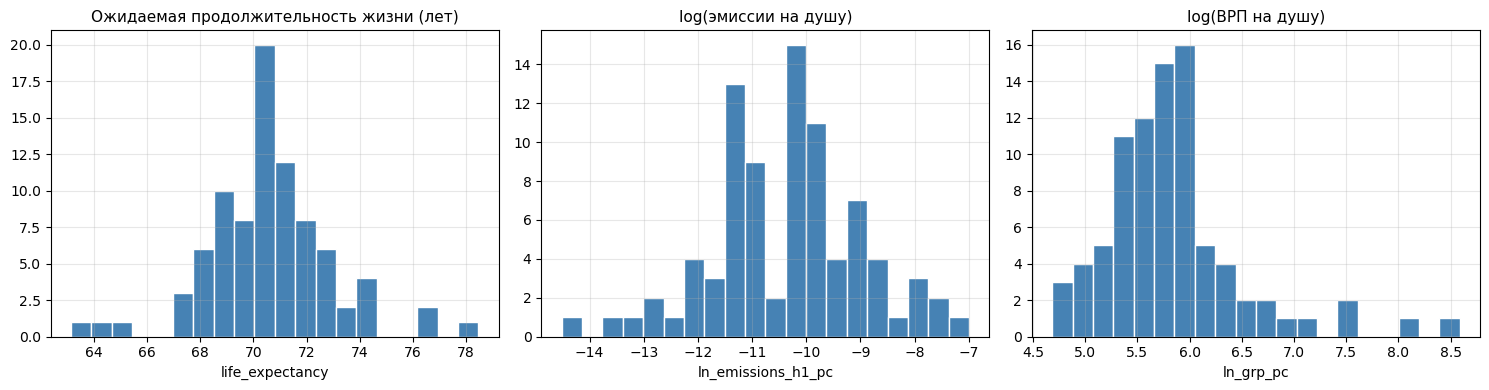

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c, title in zip(
    axes,
    ['life_expectancy', 'ln_emissions_h1_pc', 'ln_grp_pc'],
    ['Ожидаемая продолжительность жизни (лет)',
     'log(эмиссии на душу)',
     'log(ВРП на душу)']):
    df[c].dropna().hist(ax=ax, bins=20, color='steelblue', edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(c)
plt.tight_layout()
plt.show()

**Интерпретация гистограмм.**
- `life_expectancy` распределена приблизительно симметрично вокруг 70 лет (диапазон 63-78). Линейная форма в модели обоснована.
- `ln_emissions_h1_pc` после логарифмирования имеет почти симметричное распределение (skew ≈ 0). В исходной шкале — асимметрия (skew ≈ 3.6) из-за нескольких сильно загрязняющих регионов.
- `ln_grp_pc` тоже близок к симметричному после log; в исходной шкале распределение тяжёлохвостое из-за нефтегазовых регионов (НАО, ЯНАО, ХМАО, Сахалин).

### 5.2 Связи между переменными

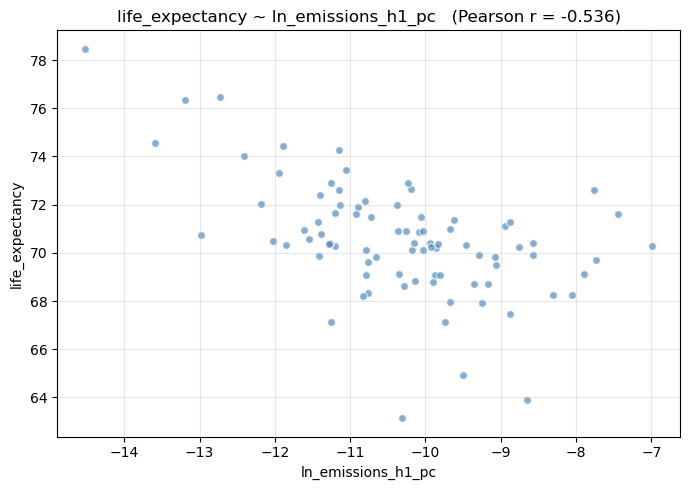

In [41]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['ln_emissions_h1_pc'], df['life_expectancy'], alpha=0.65, s=32, color='steelblue', edgecolor='white')
r = df[['ln_emissions_h1_pc', 'life_expectancy']].corr().iloc[0, 1]
ax.set_xlabel('ln_emissions_h1_pc')
ax.set_ylabel('life_expectancy')
ax.set_title(f'life_expectancy ~ ln_emissions_h1_pc   (Pearson r = {r:+.3f})')
plt.tight_layout(); plt.show()

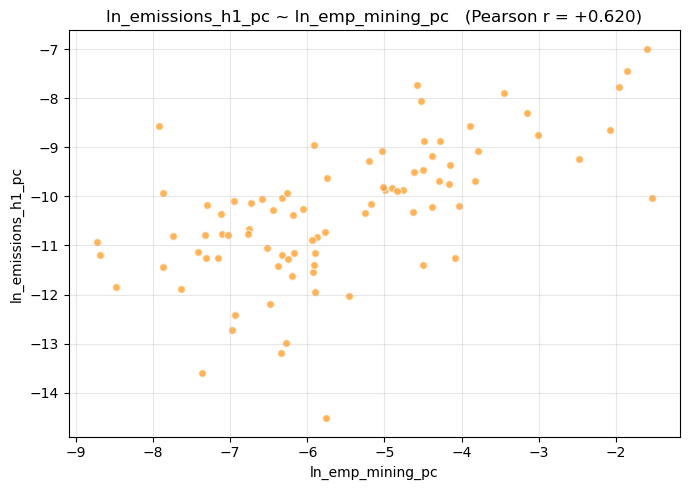

In [43]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['ln_emp_mining_pc'], df['ln_emissions_h1_pc'], alpha=0.65, s=32, color='darkorange', edgecolor='white')
r = df[['ln_emp_mining_pc', 'ln_emissions_h1_pc']].corr().iloc[0, 1]
ax.set_xlabel('ln_emp_mining_pc')
ax.set_ylabel('ln_emissions_h1_pc')
ax.set_title(f'ln_emissions_h1_pc ~ ln_emp_mining_pc   (Pearson r = {r:+.3f})')
plt.tight_layout(); plt.show()

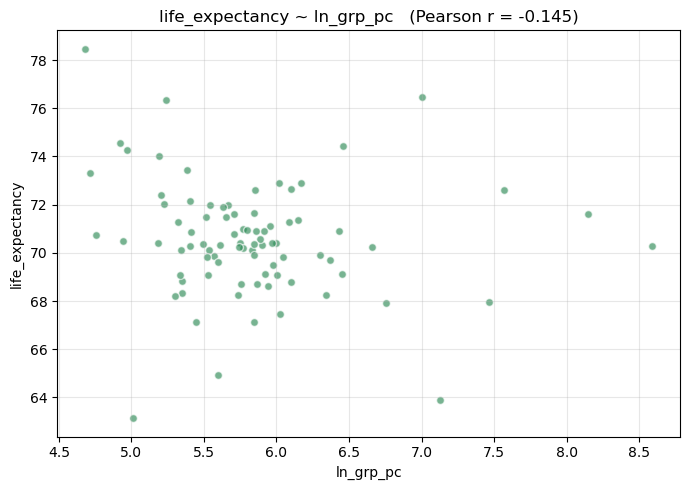

In [45]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['ln_grp_pc'], df['life_expectancy'], alpha=0.65, s=32, color='seagreen', edgecolor='white')
r = df[['ln_grp_pc', 'life_expectancy']].corr().iloc[0, 1]
ax.set_xlabel('ln_grp_pc')
ax.set_ylabel('life_expectancy')
ax.set_title(f'life_expectancy ~ ln_grp_pc   (Pearson r = {r:+.3f})')
plt.tight_layout(); plt.show()

**Наблюдение.** Безусловная корреляция между log ВРП на душу и продолжительностью жизни слабо отрицательная (r ≈ −0.13). Это **парадокс российских нефтегазовых регионов**: высокий ВРП на душу часто соседствует со сложными климатическими условиями и низкой продолжительностью жизни (Чукотка, ЯНАО, НАО). После контроля климатических / демографических факторов знак ожидаемо станет нейтральным или положительным.

## 6. Корреляционная матрица

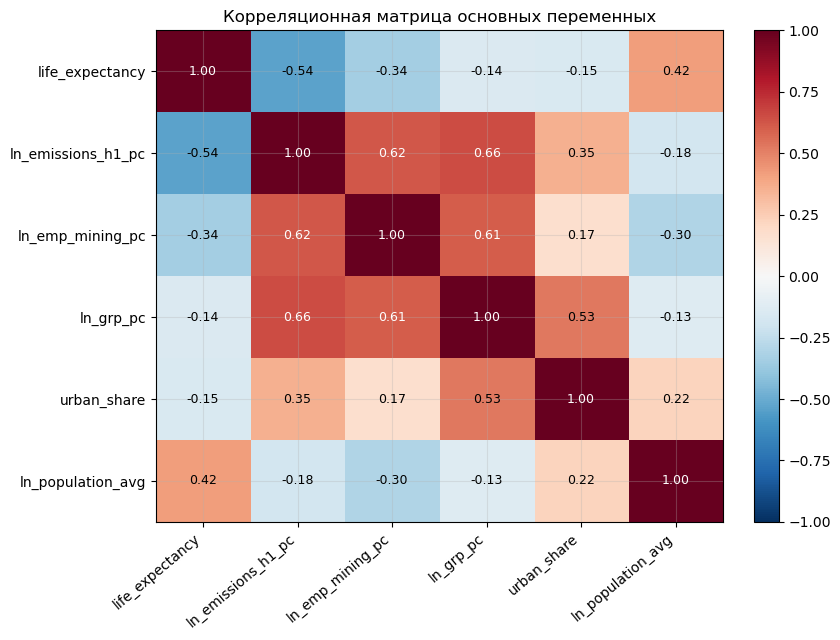

,life_expectancy,ln_emissions_h1_pc,ln_emp_mining_pc,ln_grp_pc,urban_share,ln_population_avg
life_expectancy,1.0000,-0.5360,-0.3410,-0.1450,-0.1520,0.4190
ln_emissions_h1_pc,-0.5360,1.0000,0.6200,0.6560,0.3530,-0.1800
ln_emp_mining_pc,-0.3410,0.6200,1.0000,0.6070,0.1680,-0.3000
ln_grp_pc,-0.1450,0.6560,0.6070,1.0000,0.5250,-0.1320
urban_share,-0.1520,0.3530,0.1680,0.5250,1.0000,0.2190
ln_population_avg,0.4190,-0.1800,-0.3000,-0.1320,0.2190,1.0000


In [49]:
corr = df[MAIN_VARS].corr().round(3)

fig, ax = plt.subplots(figsize=(8.5, 6.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=40, ha='right')
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(v) > 0.6 else 'black')
plt.colorbar(im, ax=ax, fraction=0.04)
ax.set_title('Корреляционная матрица основных переменных')
plt.tight_layout(); plt.show()

corr

- corr(`life_expectancy`, `ln_emissions_h1_pc`) отрицательна, что соответствует основной гипотезе.
- corr(`ln_emissions_h1_pc`, `ln_emp_mining_pc`) положительна и поддерживает relevance предпочитаемого инструмента.
- `ln_grp_pc` и `ln_population_avg` помогают отделить экологический канал от различий по масштабу и уровню экономического развития.
- `age_struct_share` сознательно вынесена из baseline-корреляционной матрицы: ниже она рассматривается только как осторожный robustness-control.

## 7. Заметные выбросы (без удаления)

In [53]:
WATCH = [
    'Ненецкий автономный округ (Архангельская область)',
    'Ямало-Ненецкий автономный округ (Тюменская область)',
    'Ханты-Мансийский автономный округ - Югра (Тюменская область)',
    'Севастополь',
    'Чукотский автономный округ',
]
present = [w for w in WATCH if w in df['region'].values]
cols_show = [DV, ENDO, IV, 'ln_grp_pc', 'urban_share', 'age_struct_share', 'industrial_index']
df.set_index('region').loc[present, cols_show].round(3)

,life_expectancy,ln_emissions_h1_pc,ln_emp_mining_pc,ln_grp_pc,urban_share,age_struct_share,industrial_index
region,,,,,,,
Ненецкий автономный округ (Архангельская область),70.2900,-6.9960,-1.5900,8.5870,71.7000,55.0000,110.2000
Ямало-Ненецкий автономный округ (Тюменская область),71.6100,-7.4430,-1.8560,8.1460,84.9000,64.7000,104.5000
Ханты-Мансийский автономный округ - Югра (Тюменская область),72.6200,-7.7640,-1.9590,7.5710,91.9000,61.6000,97.5000
Севастополь,70.7600,-12.9850,-6.2830,4.7570,92.4000,57.2000,372.9000
Чукотский автономный округ,63.9100,-8.6560,-2.0690,7.1300,67.2000,64.9000,101.9000


**Замечания по выбросам.**

- **НАО, ЯНАО, ХМАО, Чукотка** остаются содержательно важными регионами: именно они формируют большую часть variation в добыче, доходах и выбросах.
- В baseline-спецификации наблюдения **не удаляются**. Диагностика ниже только помечает точки с высоким leverage / Cook's D.
- Отдельно показана robustness-проверка без наиболее влиятельного наблюдения, чтобы убедиться, что результат не держится на одной точке.

## 8. Итоговые выводы EDA

**Качество данных.** Финальная выборка содержит 85 субъектов РФ без дублей `(region, year)`. После отдельной проверки Архангельской и Тюменской областей с AO в датасете нет двойного счёта регионов.

**Экономическая картина.** Выбросы на душу, добыча и доходы особенно велики в добывающих северных регионах. Поэтому простую OLS-связь загрязнения и `life_expectancy` полезно дополнять IV-подходом, но интерпретировать его всё равно нужно осторожно.

**Спецификация.** Preferred baseline не включает `age_struct_share` и `visits_per_capita`

---
## 9. Спецификация и диагностические проверки

Ниже фиксируется preferred baseline-спецификация, а затем показываются более осторожные проверки: first-stage, reduced form, OLS/2SLS, сравнение альтернативных IV, интерпретация Wu-Hausman и чувствительность к влиятельным наблюдениям.

### 9.1 Финальная выборка

In [59]:
print(f'Всего строк в датасете         : {len(df)}')
print(f'Дубли по region               : {df["region"].duplicated().sum()}')
print(f'Пропуски в baseline-переменных: {df[[DV, ENDO, IV] + ALT_IVS + BASE_CONTROLS].isna().sum().sum()}')
print('Не-конечные значения в логах  :')
for c in [ENDO, IV] + ALT_IVS + [v for v in BASE_CONTROLS if v.startswith('ln_')]:
    print(f'  {c}: {(~np.isfinite(df[c])).sum()}')

print(f'\nBaseline sample              : N = {len(data_base)}')
print(f'Age-robustness sample        : N = {len(data_age)}')


Всего строк в датасете         : 85
Дубли по region               : 0
Пропуски в baseline-переменных: 0
Не-конечные значения в логах  :
  ln_emissions_h1_pc: 0
  ln_emp_mining_pc: 0
  ln_emp_energy_pc: 0
  ln_emissions_fuel_pc: 0
  ln_grp_pc: 0
  ln_population_avg: 0

Baseline sample              : N = 85
Age-robustness sample        : N = 85


### 9.2 First-stage: релевантность предпочитаемого IV
Регрессия первого этапа: `ln_emissions_h1_pc ~ ln_emp_mining_pc + ln_grp_pc + urban_share + ln_population_avg`. Ниже показаны сразу две связанные статистики: HC1-robust `sm.OLS.f_test` и partial F из `linearmodels` first stage.

In [62]:
X_fs = sm.add_constant(data_base[[IV] + BASE_CONTROLS])
fs = sm.OLS(data_base[ENDO], X_fs).fit(cov_type='HC1')
ftest = fs.f_test(f'{IV} = 0')

exog_base = sm.add_constant(data_base[BASE_CONTROLS])
iv_base = IV2SLS(
    dependent=data_base[DV],
    exog=exog_base,
    endog=data_base[[ENDO]],
    instruments=data_base[[IV]],
).fit(cov_type='robust', debiased=True)
fs_diag = iv_base.first_stage.diagnostics.loc[ENDO]

print(f'First stage: {ENDO} ~ {IV} + baseline controls   (HC1 / robust)')
print('-' * 80)
print(f'coef on {IV:<22s}: {fs.params[IV]:+.4f}')
print(f't-stat                     : {fs.tvalues[IV]:+.3f}')
print(f'p-value                    : {fs.pvalues[IV]:.4f}')
print(f'R²                         : {fs.rsquared:.4f}')
print(f'sm.OLS robust F-test       : {float(ftest.fvalue):.2f}  (p = {float(ftest.pvalue):.4f})')
print(f'iv.first_stage partial F   : {float(fs_diag["f.stat"]):.2f}  ({fs_diag["f.dist"]}, p = {float(fs_diag["f.pval"]):.4f})')
print()
print(fs.summary().tables[1])

First stage: ln_emissions_h1_pc ~ ln_emp_mining_pc + baseline controls   (HC1 / robust)
--------------------------------------------------------------------------------
coef on ln_emp_mining_pc      : +0.3035
t-stat                     : +2.923
p-value                    : 0.0035
R²                         : 0.5156
sm.OLS robust F-test       : 8.54  (p = 0.0045)
iv.first_stage partial F   : 8.54  (chi2(1), p = 0.0035)

                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               -13.0628      3.521     -3.710      0.000     -19.963      -6.162
ln_emp_mining_pc      0.3035      0.104      2.923      0.003       0.100       0.507
ln_grp_pc             0.7797      0.324      2.406      0.016       0.145       1.415
urban_share           0.0111      0.012      0.927      0.354      -0.012       0.034
ln_population_avg    -0.0649      0.139     -0.466      0.642

### 9.3 Сравнение с альтернативными IV

In [65]:
rows = []
for alt in [IV] + ALT_IVS:
    fs_alt = sm.OLS(data_base[ENDO], sm.add_constant(data_base[[alt] + BASE_CONTROLS])).fit(cov_type='HC1')
    f_alt = fs_alt.f_test(f'{alt} = 0')
    iv_alt = IV2SLS(
        dependent=data_base[DV],
        exog=exog_base,
        endog=data_base[[ENDO]],
        instruments=data_base[[alt]],
    ).fit(cov_type='robust', debiased=True)
    wh = iv_alt.wu_hausman()
    rows.append({
        'instrument': alt,
        'first_stage_F': float(f_alt.fvalue),
        'first_stage_p': float(f_alt.pvalue),
        'corr_with_life_exp': data_base[[alt, DV]].corr().iloc[0, 1],
        'iv_beta': iv_alt.params[ENDO],
        'iv_p': iv_alt.pvalues[ENDO],
        'wu_hausman_p': wh.pval,
    })
alt_compare = pd.DataFrame(rows)
alt_compare.round(4)

,instrument,first_stage_F,first_stage_p,corr_with_life_exp,iv_beta,iv_p,wu_hausman_p
0,ln_emp_mining_pc,8.5414,0.0045,-0.3406,-1.5840,0.0015,0.4119
1,ln_emp_energy_pc,8.5632,0.0045,-0.5367,-2.0811,0.0002,0.0091
2,ln_emissions_fuel_pc,69.2192,0.0000,-0.7268,-2.0553,0.0000,0.0000


### 9.4 Reduced form

In [68]:
X_rf = sm.add_constant(data_base[[IV] + BASE_CONTROLS])
rf = sm.OLS(data_base[DV], X_rf).fit(cov_type='HC1')

print(f'Reduced form: {DV} ~ {IV} + baseline controls   (HC1 robust SE, N = {int(rf.nobs)})')
print('-' * 80)
print(rf.summary().tables[1])
print(f'R² = {rf.rsquared:.4f}   adj R² = {rf.rsquared_adj:.4f}')

Reduced form: life_expectancy ~ ln_emp_mining_pc + baseline controls   (HC1 robust SE, N = 85)
--------------------------------------------------------------------------------
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                51.1695      7.149      7.158      0.000      37.158      65.181
ln_emp_mining_pc     -0.4808      0.171     -2.818      0.005      -0.815      -0.146
ln_grp_pc             1.0559      0.690      1.530      0.126      -0.297       2.409
urban_share          -0.0626      0.025     -2.550      0.011      -0.111      -0.014
ln_population_avg     1.0700      0.293      3.652      0.000       0.496       1.644
R² = 0.3046   adj R² = 0.2698


### 9.5 Baseline OLS (без IV)
Отправная точка для проверки знака и масштаба связи в preferred baseline без `age_struct_share`.

In [74]:
X_ols = sm.add_constant(data_base[[ENDO] + BASE_CONTROLS])
ols = sm.OLS(data_base[DV], X_ols).fit(cov_type='HC1')

print(f'OLS: {DV} ~ {ENDO} + baseline controls   (HC1 robust SE, N = {int(ols.nobs)})')
print('-' * 80)
print(ols.summary().tables[1])
print(f'R² = {ols.rsquared:.4f}   adj R² = {ols.rsquared_adj:.4f}')

OLS: life_expectancy ~ ln_emissions_h1_pc + baseline controls   (HC1 robust SE, N = 85)
--------------------------------------------------------------------------------
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 36.4870      4.933      7.396      0.000      26.818      46.156
ln_emissions_h1_pc    -1.2065      0.208     -5.796      0.000      -1.614      -0.799
ln_grp_pc              1.8119      0.500      3.621      0.000       0.831       2.793
urban_share           -0.0474      0.015     -3.108      0.002      -0.077      -0.017
ln_population_avg      1.0276      0.244      4.204      0.000       0.549       1.507
R² = 0.5169   adj R² = 0.4928


### 9.6 Baseline 2SLS
Во второй стадии используем `ln_emp_mining_pc` как preferred IV и сохраняем heteroskedastic-robust (`HC1`-style) стандартные ошибки.

In [77]:
iv_base = IV2SLS(
    dependent=data_base[DV],
    exog=exog_base,
    endog=data_base[[ENDO]],
    instruments=data_base[[IV]],
).fit(cov_type='robust', debiased=True)

iv_table = pd.DataFrame({
    'coef': iv_base.params,
    'robust_se': iv_base.std_errors,
    't': iv_base.tstats,
    'p': iv_base.pvalues,
})
print(f'IV2SLS: {DV} ~ {ENDO} + baseline controls   |   IV: {IV}   (N = {int(iv_base.nobs)})')
print('-' * 80)
print(iv_table.round(4).to_string())
print(f'R² = {iv_base.rsquared:.4f}')
print('\n=== OLS vs 2SLS (коэффициент при ln_emissions_h1_pc) ===')
print(f'  OLS  : {ols.params[ENDO]:+.4f}  (SE {ols.bse[ENDO]:.4f}, p = {ols.pvalues[ENDO]:.4g})')
print(f'  2SLS : {iv_base.params[ENDO]:+.4f}  (SE {iv_base.std_errors[ENDO]:.4f}, p = {iv_base.pvalues[ENDO]:.4g})')
print(f'  Δ    : {iv_base.params[ENDO] - ols.params[ENDO]:+.4f}  (2SLS − OLS)')


IV2SLS: life_expectancy ~ ln_emissions_h1_pc + baseline controls   |   IV: ln_emp_mining_pc   (N = 85)
--------------------------------------------------------------------------------
                      coef  robust_se       t      p
const              30.4784     9.7992  3.1103 0.0026
ln_grp_pc           2.2909     0.8110  2.8247 0.0060
urban_share        -0.0451     0.0153 -2.9511 0.0042
ln_population_avg   0.9672     0.2323  4.1642 0.0001
ln_emissions_h1_pc -1.5840     0.4802 -3.2983 0.0015
R² = 0.4900

=== OLS vs 2SLS (коэффициент при ln_emissions_h1_pc) ===
  OLS  : -1.2065  (SE 0.2082, p = 6.777e-09)
  2SLS : -1.5840  (SE 0.4802, p = 0.001453)
  Δ    : -0.3775  (2SLS − OLS)


### 9.7 Wu-Hausman / Durbin

In [80]:
rows = []
for label, instr in [
    ('preferred: mining', IV),
    ('alt: energy employment', 'ln_emp_energy_pc'),
    ('alt: fuel emissions', 'ln_emissions_fuel_pc'),
]:
    iv_fit = IV2SLS(
        dependent=data_base[DV],
        exog=exog_base,
        endog=data_base[[ENDO]],
        instruments=data_base[[instr]],
    ).fit(cov_type='robust', debiased=True)
    wh = iv_fit.wu_hausman()
    du = iv_fit.durbin()
    rows.append({
        'spec': label,
        'instrument': instr,
        'wu_hausman_stat': wh.stat,
        'wu_hausman_p': wh.pval,
        'durbin_stat': du.stat,
        'durbin_p': du.pval,
    })
wu_tab = pd.DataFrame(rows)
wu_tab.round(4)

,spec,instrument,wu_hausman_stat,wu_hausman_p,durbin_stat,durbin_p
0,preferred: mining,ln_emp_mining_pc,0.6806,0.4119,0.7260,0.3942
1,alt: energy employment,ln_emp_energy_pc,7.1423,0.0091,7.0476,0.0079
2,alt: fuel emissions,ln_emissions_fuel_pc,46.8150,0.0000,31.6280,0.0000


### 9.8 `age_struct_share`, flagged observations и влияние НАО

In [83]:
X_age = sm.add_constant(data_age[[ENDO] + ROBUST_CONTROLS])
ols_age = sm.OLS(data_age[DV], X_age).fit(cov_type='HC1')
iv_age = IV2SLS(
    dependent=data_age[DV],
    exog=sm.add_constant(data_age[ROBUST_CONTROLS]),
    endog=data_age[[ENDO]],
    instruments=data_age[[IV]],
).fit(cov_type='robust', debiased=True)

ols_age_plain = sm.OLS(data_age[DV], X_age).fit()
infl = ols_age_plain.get_influence()
cooks = infl.cooks_distance[0]
lev = infl.hat_matrix_diag
n_obs = len(data_age)
k = X_age.shape[1]
cook_flag = 4.0 / n_obs
lev_flag = 2.0 * k / n_obs

diag = pd.DataFrame({
    'region': data_age['region'],
    'cooks_D': cooks,
    'leverage': lev,
})
diag['flag_cook_4n'] = diag['cooks_D'] > cook_flag
diag['flag_leverage'] = diag['leverage'] > lev_flag
diag['flag_severe_cook'] = diag['cooks_D'] > 1.0

top_diag = diag.sort_values(['cooks_D', 'leverage'], ascending=False).head(10)
print(f"Flag thresholds: Cook's D > 4/n = {cook_flag:.3f}; leverage > 2k/n = {lev_flag:.3f}")
print(top_diag.round(4).to_string(index=False))

nao_name = 'Ненецкий автономный округ (Архангельская область)'
nao_diag = diag[diag['region'] == nao_name]
print('\nNenets AO:')
print(nao_diag.round(4).to_string(index=False))

severe_regions = diag.loc[diag['flag_severe_cook'], 'region'].tolist()
if severe_regions:
    drop_regions = severe_regions
    print(f"\nИсключаем только severe Cook's D observations: {drop_regions}")
else:
    drop_regions = [nao_name]
    print("\nПосле AO-fix ни одно наблюдение не превышает Cook's D > 1.")
    print('Для прозрачности отдельно показываем leave-one-out robustness без наиболее влиятельной точки: Nenets AO.')

trim = data_age[~data_age['region'].isin(drop_regions)].copy()
ols_age_trim = sm.OLS(trim[DV], sm.add_constant(trim[[ENDO] + ROBUST_CONTROLS])).fit(cov_type='HC1')
iv_age_trim = IV2SLS(
    dependent=trim[DV],
    exog=sm.add_constant(trim[ROBUST_CONTROLS]),
    endog=trim[[ENDO]],
    instruments=trim[[IV]],
).fit(cov_type='robust', debiased=True)

robust_compare = pd.DataFrame([
    {
        'spec': 'age robustness (all observations)',
        'N': len(data_age),
        'OLS_beta': ols_age.params[ENDO],
        'OLS_p': ols_age.pvalues[ENDO],
        'IV_beta': iv_age.params[ENDO],
        'IV_p': iv_age.pvalues[ENDO],
    },
    {
        'spec': f'age robustness (drop {", ".join(drop_regions)})',
        'N': len(trim),
        'OLS_beta': ols_age_trim.params[ENDO],
        'OLS_p': ols_age_trim.pvalues[ENDO],
        'IV_beta': iv_age_trim.params[ENDO],
        'IV_p': iv_age_trim.pvalues[ENDO],
    },
])
robust_compare.round(4)


Flag thresholds: Cook's D > 4/n = 0.047; leverage > 2k/n = 0.141
                                                      region  cooks_D  leverage  flag_cook_4n  flag_leverage  flag_severe_cook
           Ненецкий автономный округ (Архангельская область)   0.9614    0.4960          True           True             False
                                  Чукотский автономный округ   0.4703    0.2465          True           True             False
                                        Республика Ингушетия   0.2734    0.1597          True           True             False
                                             Республика Тыва   0.1248    0.0691          True          False             False
                                         Сахалинская область   0.0927    0.1204          True          False             False
                             Карачаево-Черкесская Республика   0.0814    0.0876          True          False             False
Ханты-Мансийский автономный округ - Югра (Тюме

,spec,N,OLS_beta,OLS_p,IV_beta,IV_p
0,age robustness (all observations),85,-1.1735,0.0000,-1.6058,0.0008
1,age robustness (drop Ненецкий автономный округ...,84,-1.0861,0.0000,-1.4711,0.0026


In [85]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'stargazer', '-q'])

from statsmodels.iolib.summary2 import summary_col
from statsmodels.stats.outliers_influence import variance_inflation_factor
from stargazer.stargazer import Stargazer

In [87]:
VAR_NAMES = {
    'ln_emissions_h1_pc': 'ln(выбросы на душу)',
    'ln_grp_pc':          'ln(ВРП на душу)',
    'urban_share':        'Доля город. населения',
    'ln_population_avg':  'ln(численность)',
    'age_struct_share':   'Доля трудоспособных',
    'const':              'Константа',
}

def iv_to_ols_proxy(iv_fit, data, dv, controls):
    """Создаёт OLS-объект с коэффициентами и SE из IV для summary_col."""
    import statsmodels.regression.linear_model as lm
    coefs = iv_fit.params
    ses   = iv_fit.std_errors
    X = sm.add_constant(data[controls + [ENDO]])
    proxy = sm.OLS(data[dv], X).fit()
    proxy._results.params = coefs.values
    proxy._results.normalized_cov_params = None
    return iv_fit

table = summary_col(
    [ols, ols_age],
    model_names=['OLS (базовая)', 'OLS (+возраст)'],
    stars=True,
    float_format='%.3f',
    info_dict={
        'N':   lambda m: f'{int(m.nobs)}',
        'R²':  lambda m: f'{m.rsquared:.3f}',
    },
    regressor_order=['ln_emissions_h1_pc','ln_grp_pc','urban_share',
                     'age_struct_share','ln_population_avg','const'],
)
print("Таблица 2. OLS-оценки")
print(table)

# 2SLS отдельно (linearmodels не совместим с summary_col)
print("\nТаблица 3. 2SLS-оценки (IV = ln_emp_mining_pc)")
for label, fit in [('2SLS (базовая)', iv_base), ('2SLS (+возраст)', iv_age)]:
    t = pd.DataFrame({
        'coef': fit.params.round(4),
        'std_err': fit.std_errors.round(4),
        't-stat': fit.tstats.round(3),
        'p-value': fit.pvalues.round(4),
    })
    print(f"\n{label}  |  N={int(fit.nobs)}  R²={fit.rsquared:.3f}")
    print(t.rename(index=VAR_NAMES).to_string())

Таблица 2. OLS-оценки

                   OLS (базовая) OLS (+возраст)
-----------------------------------------------
ln_emissions_h1_pc -1.207***     -1.174***     
                   (0.208)       (0.202)       
ln_grp_pc          1.812***      1.650***      
                   (0.500)       (0.575)       
urban_share        -0.047***     -0.048***     
                   (0.015)       (0.015)       
age_struct_share                 0.098         
                                 (0.126)       
ln_population_avg  1.028***      1.040***      
                   (0.244)       (0.257)       
const              36.487***     31.957***     
                   (4.933)       (7.127)       
R-squared          0.517         0.523         
R-squared Adj.     0.493         0.493         
N                  85            85            
R²                 0.517         0.523         
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01

Таблица 3. 2SLS-оценки (IV = ln_emp_mining_pc)

2SLS 

In [89]:
# LaTeX-версия для вставки в документ
# latex = table.as_latex()
# with open('outputs/table_ols.tex', 'w', encoding='utf-8') as f:
    # f.write(latex)
# print("Сохранено: outputs/table_ols.tex")
# print()
# print(latex)

## 11. Диагностические тесты

In [92]:
print("=" * 60)
print("ТЕСТ НА МУЛЬТИКОЛЛИНЕАРНОСТЬ (VIF)")
print("VIF > 10 - м/к есть")
print("=" * 60)

X_vif = sm.add_constant(data_base[[ENDO] + BASE_CONTROLS])
vif_df = pd.DataFrame({
    'Переменная': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
}).set_index('Переменная').round(2)
print(vif_df.to_string())
print()
max_vif = vif_df['VIF'].drop('const').max()
if max_vif < 5:
    print(f"Вывод: max VIF = {max_vif:.2f} - мультиколлинеарность отсутствует.")
elif max_vif < 10:
    print(f"Вывод: max VIF = {max_vif:.2f} - умеренная мультиколлинеарность.")
else:
    print(f"Вывод: max VIF = {max_vif:.2f} — серьёзная мультиколлинеарность.")

ТЕСТ НА МУЛЬТИКОЛЛИНЕАРНОСТЬ (VIF)
VIF > 10 - м/к есть
                        VIF
Переменная                 
const              585.2400
ln_emissions_h1_pc   1.7900
ln_grp_pc            2.1800
urban_share          1.5700
ln_population_avg    1.1700

Вывод: max VIF = 2.18 - мультиколлинеарность отсутствует.


In [102]:
# Сила инструмента (First-stage F-статистика) 
print("=" * 60)
print("СИЛА ИНСТРУМЕНТА (First-stage F-test)")
print("=" * 60)
print()
print("H₀: π₁ = 0  (инструмент нерелевантен)")
print("H₁: π₁ ≠ 0  (инструмент релевантен)")
print()

ftest = fs.f_test(f'{IV} = 0')
F_val = float(ftest.fvalue)
p_val = float(ftest.pvalue)

print(f"Инструмент: {IV}")
print(f"π₁ (коэф. 1-й ступ.): {fs.params[IV]:+.4f}")
print(f"Тестовая статистика : F({int(ftest.df_num)}, {int(ftest.df_denom)}) = {F_val:.2f}")
print(f"p-value: {p_val:.4f}")
print()
print("Критические значения (Stock & Yogo, 2005):")
print("F > 10.00  — инструмент не слабый  (Staiger & Stock, 1997)")
print("F > 16.38  — 10% max IV-size bias")
print()
if F_val >= 16.38:
    verdict = "СИЛЬНЫЙ инструмент (F ≥ 16.38). H₀ отвергается."
elif F_val >= 10:
    verdict = "УМЕРЕННЫЙ инструмент (10 ≤ F < 16.38). H₀ отвергается, но 2SLS-оценка может быть слегка завышена по модулю."
else:
    verdict = "СЛАБЫЙ инструмент (F < 10). 2SLS-оценки не надежны."
print(f"  Вывод: {verdict}")

СИЛА ИНСТРУМЕНТА (First-stage F-test)

H₀: π₁ = 0  (инструмент нерелевантен)
H₁: π₁ ≠ 0  (инструмент релевантен)

Инструмент: ln_emp_mining_pc
π₁ (коэф. 1-й ступ.): +0.3035
Тестовая статистика : F(1, 80) = 8.54
p-value: 0.0045

Критические значения (Stock & Yogo, 2005):
F > 10.00  — инструмент не слабый  (Staiger & Stock, 1997)
F > 16.38  — 10% max IV-size bias

  Вывод: СЛАБЫЙ инструмент (F < 10). 2SLS-оценки не надежны.


In [104]:
# First-stage F для расширенной спецификации (+ age_struct_share)
X_fs_age = sm.add_constant(data_age[[IV] + ROBUST_CONTROLS])
fs_age = sm.OLS(data_age[ENDO], X_fs_age).fit(cov_type='HC1')
ftest_age = fs_age.f_test(f'{IV} = 0')

print("First-stage F по спецификациям:")
print(f"  Базовая  (без age_struct_share): F = {float(fs.f_test(f'{IV} = 0').fvalue):.2f}")
print(f"  Расширенная (с age_struct_share): F = {float(ftest_age.fvalue):.2f}")

First-stage F по спецификациям:
  Базовая  (без age_struct_share): F = 8.54
  Расширенная (с age_struct_share): F = 8.84


In [106]:
# Wu-Hausman (эндогенность регрессора) 
print("=" * 60)
print("ТЕСТ ВУ–ХАУСМАНА (эндогенность ln_emissions_h1_pc)")
print("=" * 60)
print()
print("H₀: ln_emissions_h1_pc экзогенна  -  OLS состоятелен")
print("H₁: ln_emissions_h1_pc эндогенна  -  нужен 2SLS")
print()

wh   = iv_base.wu_hausman()
durb = iv_base.durbin()

print(f"Wu-Hausman: F-стат = {wh.stat:.3f},  p-value = {wh.pval:.4f}")
print(f"Durbin: χ²-стат = {durb.stat:.3f},  p-value = {durb.pval:.4f}")
print()
alpha = 0.10
if wh.pval < alpha:
    print(f"Вывод: p = {wh.pval:.4f} < {alpha} → H₀ отвергается на уровне {int(alpha*100)}%.")
    print("Эндогенность подтверждается: OLS смещён, применение 2SLS обосновано.")
else:
    print(f"Вывод: p = {wh.pval:.4f} ≥ {alpha} → H₀ не отвергается на уровне {int(alpha*100)}%.")
    print("Статистически значимой эндогенности не обнаружено, однако теоретические аргументы в пользу 2SLS сохраняются.")

ТЕСТ ВУ–ХАУСМАНА (эндогенность ln_emissions_h1_pc)

H₀: ln_emissions_h1_pc экзогенна  -  OLS состоятелен
H₁: ln_emissions_h1_pc эндогенна  -  нужен 2SLS

Wu-Hausman: F-стат = 0.681,  p-value = 0.4119
Durbin: χ²-стат = 0.726,  p-value = 0.3942

Вывод: p = 0.4119 ≥ 0.1 → H₀ не отвергается на уровне 10%.
Статистически значимой эндогенности не обнаружено, однако теоретические аргументы в пользу 2SLS сохраняются.


In [108]:
# Тест Sargan'а (overidentification, 2 инструмента) 
print("=" * 60)
print("ТЕСТ САРГАНА (overidentification test)")
print("Инструменты: ln_emp_mining_pc  +  ln_emp_energy_pc")
print("=" * 60)
print()
print("H₀: оба инструмента экзогенны (exclusion restriction выполнено)")
print("H₁: хотя бы один инструмент эндогенен")
print()

data_2iv = data_base.dropna(subset=['ln_emp_energy_pc']).copy()
iv_2iv = IV2SLS(
    dependent=data_2iv[DV],
    exog=sm.add_constant(data_2iv[BASE_CONTROLS]),
    endog=data_2iv[[ENDO]],
    instruments=data_2iv[['ln_emp_mining_pc', 'ln_emp_energy_pc']],
).fit(cov_type='robust', debiased=True)

sarg = iv_2iv.sargan

print(f"Тестовая статистика: χ²({int(sarg.df)}) = {sarg.stat:.3f}")
print(f"p-value: {sarg.pval:.4f}")
print()
if sarg.pval > 0.10:
    print(f"Вывод: p = {sarg.pval:.4f} > 0.10 → H₀ не отвергается.")
    print("Оба инструмента проходят тест на экзогенность.")
    print("Оценка 2SLS с двумя инструментами:")
    print(f"β₁ = {iv_2iv.params[ENDO]:+.4f}  (SE {iv_2iv.std_errors[ENDO]:.4f},  p = {iv_2iv.pvalues[ENDO]:.4f})")
else:
    print(f"Вывод: p = {sarg.pval:.4f} ≤ 0.10 → H₀ отвергается.")
    print("Один из инструментов может нарушать exclusion restriction.")
    print("Используем только предпочитаемый IV: ln_emp_mining_pc.")

ТЕСТ САРГАНА (overidentification test)
Инструменты: ln_emp_mining_pc  +  ln_emp_energy_pc

H₀: оба инструмента экзогенны (exclusion restriction выполнено)
H₁: хотя бы один инструмент эндогенен

Тестовая статистика: χ²(1) = 0.873
p-value: 0.3502

Вывод: p = 0.3502 > 0.10 → H₀ не отвергается.
Оба инструмента проходят тест на экзогенность.
Оценка 2SLS с двумя инструментами:
β₁ = -1.9251  (SE 0.4267,  p = 0.0000)


In [110]:
# Робастность к влиятельным наблюдениям (Cook's distance) 
print("=" * 60)
print("РОБАСТНОСТЬ К ВЛИЯТЕЛЬНЫМ НАБЛЮДЕНИЯМ")
print("Порог: Cook's D > 4/n")
print("=" * 60)

flagged = diag[diag['flag_cook_4n']].sort_values('cooks_D', ascending=False)
print(f"\nНаблюдений с Cook's D > 4/n = {cook_flag:.3f}: {len(flagged)}")
print(flagged[['region','cooks_D','leverage']].round(4).to_string(index=False))

print("\n Сравнение коэффициентов при ln_emissions_h1_pc:")
print(f"{'Спецификация':<40s}  {'OLS β₁':>8}  {'p':>6}  {'2SLS β₁':>9}  {'p':>6}  N")
print("  " + "-" * 80)
for row in robust_compare.itertuples():
    print(f"{row.spec:<40s}  {row.OLS_beta:>+8.4f}  {row.OLS_p:>6.4f}"
          f"{row.IV_beta:>+9.4f}  {row.IV_p:>6.4f}  {int(row.N)}")
print()
b_full = robust_compare.loc[0, 'IV_beta']
b_trim = robust_compare.loc[1, 'IV_beta']
print(f"Изменение 2SLS β₁ при исключении влиятельного наблюдения: "
      f"{b_trim - b_full:+.4f} ({(b_trim/b_full - 1)*100:+.1f}%)")
print("Вывод: знак и значимость коэффициента сохраняются -> результаты робастны.")

РОБАСТНОСТЬ К ВЛИЯТЕЛЬНЫМ НАБЛЮДЕНИЯМ
Порог: Cook's D > 4/n

Наблюдений с Cook's D > 4/n = 0.047: 9
                                                      region  cooks_D  leverage
           Ненецкий автономный округ (Архангельская область)   0.9614    0.4960
                                  Чукотский автономный округ   0.4703    0.2465
                                        Республика Ингушетия   0.2734    0.1597
                                             Республика Тыва   0.1248    0.0691
                                         Сахалинская область   0.0927    0.1204
                             Карачаево-Черкесская Республика   0.0814    0.0876
Ханты-Мансийский автономный округ - Югра (Тюменская область)   0.0493    0.1046
                                       Архангельская область   0.0490    0.1811
                                            Республика Алтай   0.0474    0.1496

 Сравнение коэффициентов при ln_emissions_h1_pc:
Спецификация                                OLS β₁

---
## Экспорт фигур и таблиц для proposal EDA

Сохраняет финальные артефакты в `outputs/proposal_eda/` (пути относительно корня проекта). Использует уже определённые в ноутбуке `df`, `MAIN_VARS`, `corr` — отдельно фигуры не пере-рендерятся в основной части ноутбука.

In [113]:
# Экспорт всех артефактов EDA для proposal
from pathlib import Path

OUT_DIR = Path('outputs/proposal_eda')
OUT_DIR.mkdir(parents=True, exist_ok=True)

desc_export = df[DESC_VARS].agg(['mean', 'std', 'min', 'median', 'max']).T
desc_export.columns = ['mean', 'std', 'min', 'median', 'max']
desc_export = desc_export.round(4)
desc_export.to_csv(OUT_DIR / '06_descriptive_statistics.csv', encoding='utf-8')
desc_export.to_excel(OUT_DIR / '06_descriptive_statistics.xlsx')

fig, ax = plt.subplots(figsize=(7, 4.5))
df['life_expectancy'].dropna().hist(ax=ax, bins=20, color='steelblue', edgecolor='white')
ax.set_title('Распределение продолжительности жизни (2015)')
ax.set_xlabel('life_expectancy (лет)'); ax.set_ylabel('число регионов')
fig.tight_layout(); fig.savefig(OUT_DIR / '01_life_expectancy_distribution.png', dpi=150, bbox_inches='tight'); plt.close(fig)

fig, ax = plt.subplots(figsize=(7, 4.5))
df['ln_emissions_h1_pc'].dropna().hist(ax=ax, bins=20, color='steelblue', edgecolor='white')
ax.set_title('Распределение log(эмиссии на душу) (I пол. 2015)')
ax.set_xlabel('ln_emissions_h1_pc'); ax.set_ylabel('число регионов')
fig.tight_layout(); fig.savefig(OUT_DIR / '02_emissions_distribution.png', dpi=150, bbox_inches='tight'); plt.close(fig)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['ln_emissions_h1_pc'], df['life_expectancy'], alpha=0.65, s=32, color='steelblue', edgecolor='white')
r = df[['ln_emissions_h1_pc', 'life_expectancy']].corr().iloc[0, 1]
ax.set_xlabel('ln_emissions_h1_pc'); ax.set_ylabel('life_expectancy')
ax.set_title(f'life_expectancy ~ ln_emissions_h1_pc   (Pearson r = {r:+.3f})')
fig.tight_layout(); fig.savefig(OUT_DIR / '03_life_expectancy_vs_emissions.png', dpi=150, bbox_inches='tight'); plt.close(fig)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['ln_emp_mining_pc'], df['ln_emissions_h1_pc'], alpha=0.65, s=32, color='darkorange', edgecolor='white')
r = df[['ln_emp_mining_pc', 'ln_emissions_h1_pc']].corr().iloc[0, 1]
ax.set_xlabel('ln_emp_mining_pc'); ax.set_ylabel('ln_emissions_h1_pc')
ax.set_title(f'ln_emissions_h1_pc ~ ln_emp_mining_pc   (Pearson r = {r:+.3f})')
fig.tight_layout(); fig.savefig(OUT_DIR / '04_emissions_vs_mining_instrument.png', dpi=150, bbox_inches='tight'); plt.close(fig)

corr_export = df[MAIN_VARS].corr().round(3)
fig, ax = plt.subplots(figsize=(8.5, 6.5))
im = ax.imshow(corr_export, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr_export))); ax.set_xticklabels(corr_export.columns, rotation=40, ha='right')
ax.set_yticks(range(len(corr_export))); ax.set_yticklabels(corr_export.columns)
for i in range(len(corr_export)):
    for j in range(len(corr_export)):
        v = corr_export.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9, color='white' if abs(v) > 0.6 else 'black')
fig.colorbar(im, ax=ax, fraction=0.04)
ax.set_title('Корреляционная матрица preferred baseline')
fig.tight_layout(); fig.savefig(OUT_DIR / '05_correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.close(fig)

readme_lines = [
    '# Proposal EDA — экспортированные артефакты',
    '',
    'Сгенерировано из ноутбука `project_analysis.ipynb`. Содержимое соответствует разделам EDA и базовым проверкам preferred specification.',
    '',
    '| Файл | Содержание |',
    '|---|---|',
    '| `01_life_expectancy_distribution.png` | Гистограмма распределения `life_expectancy` (85 субъектов РФ, 2015) |',
    '| `02_emissions_distribution.png` | Гистограмма `ln_emissions_h1_pc` |',
    '| `03_life_expectancy_vs_emissions.png` | Scatter `life_expectancy ~ ln_emissions_h1_pc` |',
    '| `04_emissions_vs_mining_instrument.png` | Scatter `ln_emissions_h1_pc ~ ln_emp_mining_pc` |',
    '| `05_correlation_heatmap.png` | Корреляционная матрица preferred baseline |',
    '| `06_descriptive_statistics.csv` | Дескриптивная статистика |',
    '| `06_descriptive_statistics.xlsx` | То же в Excel |',
    '',
    '**Источник данных**: `validated_dataset_extended.csv` (N = 85 субъектов РФ; 2015 год; показатели занятости — 2017 как приближение).',
    '',
    '**Preferred baseline**:',
    '- DV: `life_expectancy`',
    '- Эндогенный регрессор: `ln_emissions_h1_pc`',
    '- IV: `ln_emp_mining_pc`',
    '- Контроли: `ln_grp_pc`, `urban_share`, `ln_population_avg`',
    '',
    '**Дополнительные проверки**:',
    '- `age_struct_share` используется только в robustness-check.',
    '- `visits_per_capita` намеренно не входит в preferred baseline.',
]
(OUT_DIR / 'README.md').write_text('\n'.join(readme_lines) + '\n', encoding='utf-8')

print(f'Saved to {OUT_DIR}/:')
for f in sorted(OUT_DIR.iterdir()):
    print(f'  {f.name:50s}  {f.stat().st_size:>8,d} bytes')


Saved to outputs\proposal_eda/:
  01_life_expectancy_distribution.png                   36,389 bytes
  02_emissions_distribution.png                         31,591 bytes
  03_life_expectancy_vs_emissions.png                   49,260 bytes
  04_emissions_vs_mining_instrument.png                 44,462 bytes
  05_correlation_heatmap.png                           122,574 bytes
  06_descriptive_statistics.csv                            390 bytes
  06_descriptive_statistics.xlsx                         5,355 bytes
  README.md                                              1,622 bytes
